# Setup

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [15]:
import sys
sys.path.append("../")

from utils.seed_all import seed_all

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

In [16]:
def plot_img_loss(img_loss, min=None, max=None, targets=[]):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i - 0.5, color='red', linewidth=1.5, alpha=0.1)  # top edge
            plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title("Mean Image Loss Map")
    plt.tight_layout()
    plt.show()
    plt.close()

# Load data

In [17]:
df = pd.read_csv('../data/tow-ids-dataset/raw/pkt_train.csv')

/var/folders/fs/f8qz96w55l1cqqbyb70x11380000gn/T/ipykernel_85531/2512988773.py:1: DtypeWarning:

Columns (111,115,116,117,119,121,122,123,124,125,127,130,132,133,134,135,136,137,138,141,142,143,145,146,150,151,152,153,154,155,156,157,160,162,163,164,165,166,167,172,173) have mixed types. Specify dtype option on import or set low_memory=False.



In [ ]:
# # GROUP 1: PTP
# eth:ethertype:ptp


# # GROUP 2: AVTP
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mp2t:mpeg-pes
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg-pes:mp2t:mpeg-pes
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg_sect:mpeg_pat:mp2t:mpeg_sect:mpeg_pmt
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg-pes:h264:mp2t:mpeg-pes
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mp2t:mpeg-pes:h264
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg-pes:mp2t:mpeg_sect:mpeg_pat
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg_sect:mpeg_pmt:mp2t
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg-pes:mp2t
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg-pes:h264:mp2t:mpeg_sect:mpeg_pat
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg-pes:h264:mp2t
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg-pes:h264
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg_sect:mpeg_pmt:mp2t:data
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:data:mp2t
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg_sect:mpeg_pmt:mp2t:mpeg-pes:h264
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg-pes:mp2t:data
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mpeg-pes:mp2t:mpeg-pes:h264
# eth:ethertype:vlan:ethertype:ieee1722:iec61883:mp2t:mp2t
# eth:ethertype:ieee1722:ieee17221


# # GROUP 3: UDP
# eth:ethertype:ip
# eth:ethertype:ipv6:icmpv6
# eth:ethertype:ip:udp:data
# eth:ethertype:ip:udp:dhcp 
# eth:ethertype:ip:udp:mdns
# eth:ethertype:ipv6:udp:mdns 

 
# # GROUP 4: 
# eth:ethertype:arp
# eth:ethertype:mrp-mvrp
# eth:ethertype:mrp-msrp

In [30]:
def detect_protocol_group(pkt):
    if 'ieee1722' in pkt:
        return 'ieee1722'

    if 'ptp' in pkt:
        return 'PTP'
    
    if 'ipv6' in pkt:
        return 'IPv6/UDP'
    
    if 'ip' in pkt:
        return 'IP/UDP'
    
    if 'arp' in pkt:
        return 'ARP'
    
    if 'mrp' in pkt:
        return 'MRP'
    
    return pkt

df['proto_group'] = df['frame.protocols'].apply(detect_protocol_group)

In [19]:
def detect_protocol(pkt):
    if 'ieee1722' in pkt:
        return 'AVTP'

    if 'ptp' in pkt:
        return 'PTP'
    
    if 'ip' in pkt or 'ipv6' in pkt:
        return 'IP/UDP'
    
    return 'L2'

df['proto'] = df['frame.protocols'].apply(detect_protocol)

# Explore

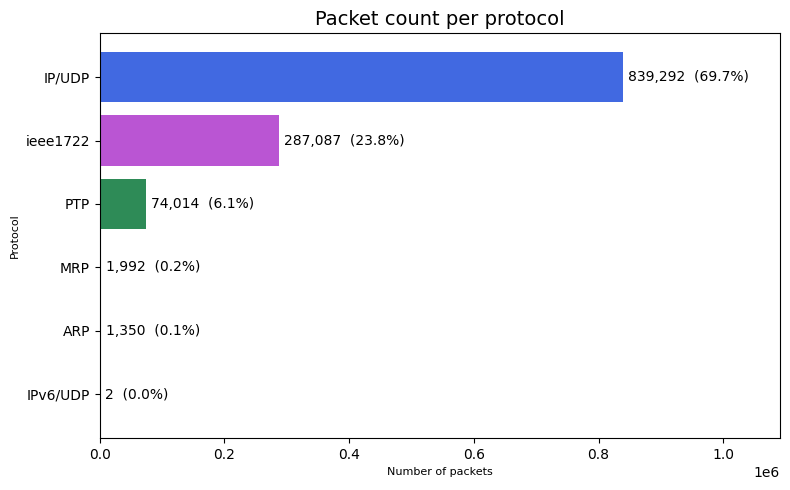

In [31]:
# Value counts
counts = df["proto_group"].value_counts().sort_values()

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

color_map = {
    "IP/UDP": "royalblue",
    "IPv6/UDP": "royalblue",
    "ieee1722": "mediumorchid",
    "PTP": "seagreen"
}
colors = [color_map.get(proto, "goldenrod") for proto in counts.index]

# Plot bars
bars = ax.barh(counts.index, counts.values, color=colors)

# Annotate counts + percentages
total = counts.sum()
for bar, v in zip(bars, counts.values):
    ax.text(
        v + 0.01 * counts.max(),  # position a bit outside the bar
        bar.get_y() + bar.get_height()/2,
        f"{v:,}  ({v/total:.1%})",
        va="center"
    )

ax.set_xlim(0, counts.max() * 1.3)  # 15% extra space on the right

# Titles and labels
ax.set_title("Packet count per protocol", fontsize=14,)
ax.set_xlabel("Number of packets", fontsize=8)
ax.set_ylabel("Protocol", fontsize=8)

# Clean layout
plt.tight_layout()
plt.show()

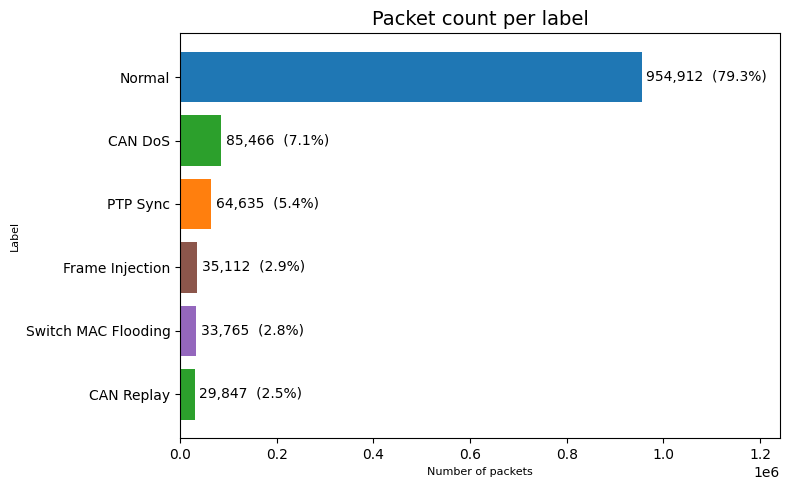

In [41]:
# Value counts
counts = df["label"].value_counts().sort_values()

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#2ca02c", "#9467bd", "#8c564b", "#ff7f0e", "#2ca02c", "#1f77b4"]

# Plot bars
bars = ax.barh(counts.index, counts.values, color=colors)

# Annotate counts + percentages
total = counts.sum()
for bar, v in zip(bars, counts.values):
    ax.text(
        v + 0.01 * counts.max(),  # position a bit outside the bar
        bar.get_y() + bar.get_height()/2,
        f"{v:,}  ({v/total:.1%})",
        va="center"
    )

ax.set_xlim(0, counts.max() * 1.3)  # 15% extra space on the right

# Titles and labels
ax.set_title("Packet count per label", fontsize=14,)
ax.set_xlabel("Number of packets", fontsize=8)
ax.set_ylabel("Label", fontsize=8)

# Clean layout
plt.tight_layout()
plt.show()

In [53]:
df.groupby('proto')['frame.len'].unique()

proto
AVTP                    [434, 82, 242]
IP/UDP    [60, 342, 384, 70, 238, 160]
L2                            [60, 42]
PTP                       [60, 90, 68]
Name: frame.len, dtype: object

In [93]:
df['proto_delta'] = df.groupby('proto')['frame.time_epoch'].diff() * 1e6
df['proto_delta'] = df['proto_delta']
df.groupby('proto')['proto_delta'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
proto,,,,
AVTP,2191.434430,6753.688448,7.867813,410724.163055
IP/UDP,799.951419,777.998723,5.006790,19213.199615
L2,165200.233174,226655.917831,3.814697,815023.899078
PTP,58875.464585,59722.036350,122.070312,125648.975372
